# Pandora Lung Atlas — cross-species embedding

This notebook follows the validated Pandora path from annotation and orthology gates to matched legacy scores and the already-generated score-matched UMAPs.


## Protocol contract

Eleven species are evaluated on a physically filtered 93,423-cell atlas. `species` is the scIB batch key; the biological label is `cell_type_ontology_term_id`.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scprint2.preprocessing.pandora import (
    PandoraBenchmarkConfig,
    build_benchmark_data,
    canonical_mouse_symbol,
    filter_h5ad_by_obs_labels,
    summarize_pandora_annotations,
    summarize_pandora_orthology,
)

REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
RESULT_ROOT = REPO_ROOT / "data/results/cross_species_embedding/pandora_lung"
AUDIT = RESULT_ROOT / "annotation_audit_filtered_93423.tsv"
ORTHOLOGS = REPO_ROOT / "notebooks/scPRINT-2-repro-notebooks/data/mouse_to_human_one2one_orthologs.tsv"
LEGACY_SCORES = RESULT_ROOT / "pandora_lung_filtered_93423_scib113_five_methods.tsv"
EVALUATOR_COMPARISON = RESULT_ROOT / "pandora_lung_filtered_93423_scib113_five_methods_vs_modern.tsv"
LEGACY_METADATA = RESULT_ROOT / "pandora_lung_filtered_93423_scib113_five_methods.metadata.json"
COMPLETE = RESULT_ROOT / "pandora_lung_filtered_93423_scib113_five_methods.COMPLETE"
UMAP_ROOT = RESULT_ROOT / "pandora_task3_matched_umaps_20260818"
UMAP_DATA = UMAP_ROOT / "pandora_task3_matched_umaps.h5ad"
UMAP_METADATA = UMAP_ROOT / "pandora_task3_matched_umaps.metadata.json"
RUN_PREPARATION = False


No module named 'adasplash'
FlashAttention is not installed, not using it..


## Artifact registry

The score table, evaluator comparison, metadata, completion marker, UMAP coordinates, and UMAP validation markers are separate evidence.


In [2]:
artifact_registry = pd.DataFrame({
    "artifact": ["legacy scores", "evaluator comparison", "legacy metadata", "score complete", "UMAP coordinates", "UMAP metadata", "UMAP complete", "UMAP validation"],
    "path": [LEGACY_SCORES, EVALUATOR_COMPARISON, LEGACY_METADATA, COMPLETE, UMAP_DATA, UMAP_METADATA, UMAP_ROOT / "COMPLETE", UMAP_ROOT / "VALIDATION_OK"],
})
artifact_registry["exists"] = artifact_registry["path"].map(Path.exists)
display(artifact_registry)
assert artifact_registry["exists"].all()


,artifact,path,exists
0,legacy scores,/Users/jkobject/Documents/scPRINT/data/results...,True
1,evaluator comparison,/Users/jkobject/Documents/scPRINT/data/results...,True
2,legacy metadata,/Users/jkobject/Documents/scPRINT/data/results...,True
3,score complete,/Users/jkobject/Documents/scPRINT/data/results...,True
4,UMAP coordinates,/Users/jkobject/Documents/scPRINT/data/results...,True
5,UMAP metadata,/Users/jkobject/Documents/scPRINT/data/results...,True
6,UMAP complete,/Users/jkobject/Documents/scPRINT/data/results...,True
7,UMAP validation,/Users/jkobject/Documents/scPRINT/data/results...,True


## Annotation gate

The RDS metadata was inspected before conversion. Unknown, unmapped, and mixed labels are excluded physically rather than retained as benchmark classes.


In [3]:
annotation_audit = pd.read_csv(AUDIT, sep="	")
annotation_summary = summarize_pandora_annotations(annotation_audit)
assert annotation_audit["cells"].sum() == 93423
assert not annotation_audit["cell_type"].astype(str).str.casefold().isin({"unknown", "unmapped", "mix"}).any()
display(annotation_summary)


,species,cells,cell_types
0,Deer,19662,9
1,Duck,18977,9
2,Tiger,14159,8
3,Pangolin,13720,9
4,Cat,8591,10
5,Pigeon,5545,11
6,Goat,4681,13
7,Dog,4040,8
8,Lizard,1702,10
9,Hamster,1681,12


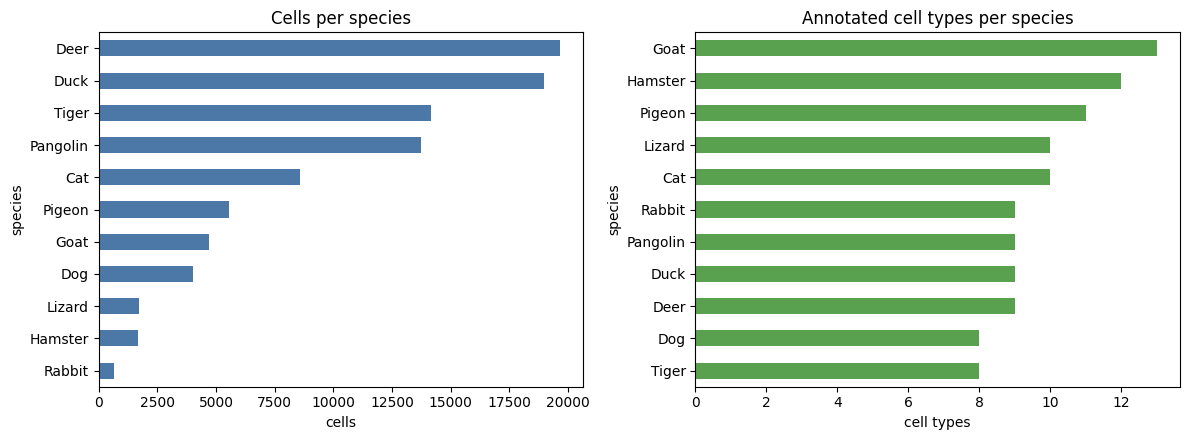

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
annotation_summary.set_index("species")["cells"].sort_values().plot.barh(ax=axes[0], color="#4c78a8", title="Cells per species")
annotation_summary.set_index("species")["cell_types"].sort_values().plot.barh(ax=axes[1], color="#59a14f", title="Annotated cell types per species")
axes[0].set_xlabel("cells")
axes[1].set_xlabel("cell types")
plt.tight_layout()


species,Cat,Deer,Dog,Duck,Goat,Hamster,Lizard,Pangolin,Pigeon,Rabbit,Tiger
cell_type,,,,,,,,,,,
AT1,2402,2000,500,1263,963,530,63,2350,145,293,2864
AT2,604,6722,884,3047,994,38,570,1173,30,47,3501
B cells,15,2419,0,146,34,6,33,9,23,17,0
Ciliated cells,1633,760,878,976,417,363,471,3459,459,84,493
Dendritic cells,0,0,0,0,8,0,0,0,0,0,0
Dendrocytes,10,0,0,0,0,0,0,0,0,0,0
Endothelial cells,696,3250,92,7287,671,306,193,4985,1188,77,1320
Fibroblasts,2218,2274,246,5807,178,300,187,1233,367,52,3966
Immune cells,0,0,0,0,0,0,0,0,1467,0,0


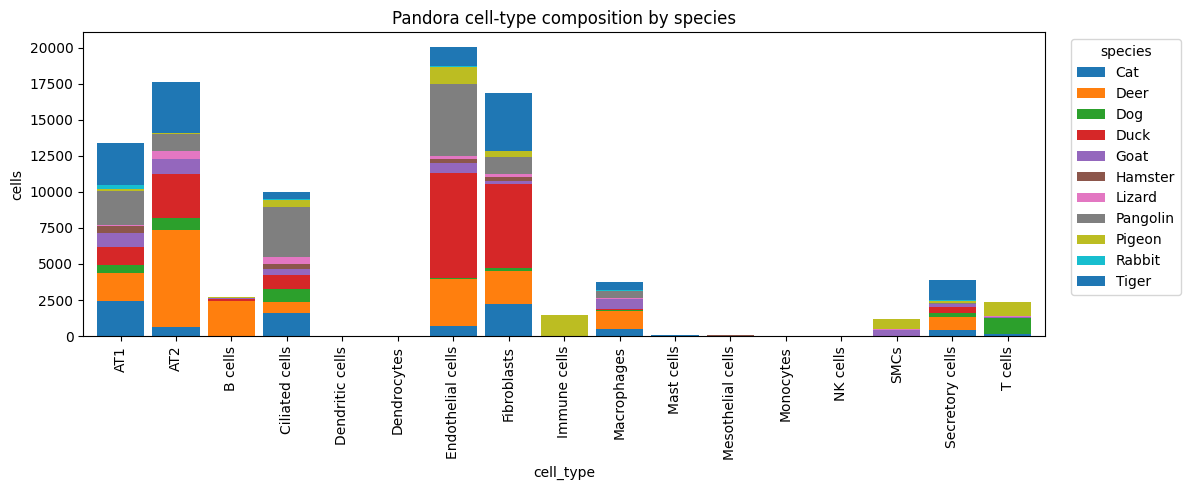

In [5]:
cell_type_matrix = annotation_audit.pivot(index="cell_type", columns="species", values="cells").fillna(0).astype(int)
display(cell_type_matrix)
ax = cell_type_matrix.plot.bar(stacked=True, figsize=(12, 5), width=0.85)
ax.set_title("Pandora cell-type composition by species")
ax.set_ylabel("cells")
ax.legend(title="species", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


## Orthology audit

Pandora source genes are mouse-homolog symbols. The table below checks the high-confidence one-to-one mouse/human mapping and duplicate policy before model input.


In [6]:
orthologs = pd.read_csv(ORTHOLOGS, sep="	", dtype=str)
display(summarize_pandora_orthology(orthologs))
display(orthologs.head())


rows                       16073
mouse_symbols              16073
mouse_ensembl_genes        16073
human_ensembl_genes        16073
one_to_one_rows            16073
high_confidence_rows       16073
duplicate_mouse_symbols        0
Name: Pandora orthology audit, dtype: int64

,mouse_gene_symbol,mouse_ensembl_gene_id,human_ensembl_gene_id,human_homology_type,human_orthology_confidence
0,0610030E20Rik,ENSMUSG00000058706,ENSG00000168887,ortholog_one2one,1
1,1110002E22Rik,ENSMUSG00000090066,ENSG00000248713,ortholog_one2one,1
2,1110004F10Rik,ENSMUSG00000030663,ENSG00000110696,ortholog_one2one,1
3,1110032F04Rik,ENSMUSG00000046999,ENSG00000180044,ortholog_one2one,1
4,1110038F14Rik,ENSMUSG00000063236,ENSG00000182307,ortholog_one2one,1


In [7]:
normalization_examples = pd.Series({
    "Mmu.1": canonical_mouse_symbol("Mmu.1"),
    "Sftpc.12": canonical_mouse_symbol("Sftpc.12"),
    "H2-D1": canonical_mouse_symbol("H2-D1"),
    "symbol.alpha": canonical_mouse_symbol("symbol.alpha"),
}, name="canonical mouse symbol")
display(normalization_examples)


Mmu.1                    Mmu
Sftpc.12               Sftpc
H2-D1                  H2-D1
symbol.alpha    symbol.alpha
Name: canonical mouse symbol, dtype: object

## Optional preparation

Filtering and benchmark assembly are separate package calls. They are disabled here because the full expression and embedding H5ADs are not stored in the notebook checkout.


In [8]:
full_atlas = Path("/path/to/pandora_full.h5ad")
filtered_atlas_path = Path("/path/to/pandora_filtered_93423.h5ad")
embedding_path = Path("/path/to/scprint2_zero_shot.h5ad")
benchmark_config = PandoraBenchmarkConfig(
    expression=filtered_atlas_path,
    embedding=embedding_path,
    embedding_key="scprint_emb_cell_type_ontology_term_id",
    embedding_name="scPRINT-2-ZS-cell-token-knn",
    output=RESULT_ROOT / "notebook_fresh_scores.tsv",
    batch_key="species",
    label_key="cell_type_ontology_term_id",
    n_jobs=8,
    seed=42,
)
display(pd.Series(benchmark_config.as_dict(), name="benchmark configuration"))


expression                            /path/to/pandora_filtered_93423.h5ad
embedding                                 /path/to/scprint2_zero_shot.h5ad
output                   /Users/jkobject/Documents/scPRINT/data/results...
embedding_key                       scprint_emb_cell_type_ontology_term_id
embedding_name                                 scPRINT-2-ZS-cell-token-knn
additional_embeddings                                                   []
batch_key                                                          species
label_key                                       cell_type_ontology_term_id
exclude_labels                                    [unknown, unmapped, mix]
seed                                                                    42
n_jobs                                                                   8
include_random                                                       False
Name: benchmark configuration, dtype: object

In [9]:
if RUN_PREPARATION:
    filtered_atlas = filter_h5ad_by_obs_labels(
        full_atlas, filtered_atlas_path,
        label_key="cell_type_ontology_term_id",
        excluded_labels=("unknown", "unmapped", "mix"),
        expected_cells=93423,
    )
    display(pd.Series(filtered_atlas.uns["pandora_cell_filter"], name="filter result"))


In [10]:
if RUN_PREPARATION:
    import anndata as ad
    expression = ad.read_h5ad(benchmark_config.expression)
    embedded = ad.read_h5ad(benchmark_config.embedding)
    benchmark_data = build_benchmark_data(
        expression, embedded, benchmark_config.embedding_key,
        benchmark_config.label_key,
        {label.casefold() for label in benchmark_config.exclude_labels},
        benchmark_config.seed,
    )
    display(pd.Series({"scored cells": benchmark_data.n_obs, "genes": benchmark_data.n_vars}, name="benchmark data"))


## Score breakdown

Legacy `scib==1.1.3` scores are read with every raw metric. Modern scores remain in a separate comparison table.


In [11]:
legacy = pd.read_csv(LEGACY_SCORES, sep="	").set_index("Method")
comparison = pd.read_csv(EVALUATOR_COMPARISON, sep="	").set_index("Method")
metadata = json.loads(LEGACY_METADATA.read_text())
assert {method["versions"]["scib"] for method in metadata["methods"].values()} == {"1.1.3"}
display(legacy[["Batch correction", "Bio conservation", "Total"]])


,Batch correction,Bio conservation,Total
Method,,,
scPRINT-2-FT-cell-token-mmd003-no-organism-classification-knn,0.515763,0.599212,0.565833
scPRINT-2-FT-all-tokens-mmd003-no-organism-classification-knn,0.516146,0.598559,0.565594
TranscriptFormer,0.481651,0.515378,0.501887
scPRINT-2-ZS-cell-token-knn,0.443185,0.417050,0.427504
scPRINT-2-ZS-all-tokens-pca50,0.348242,0.429156,0.396790


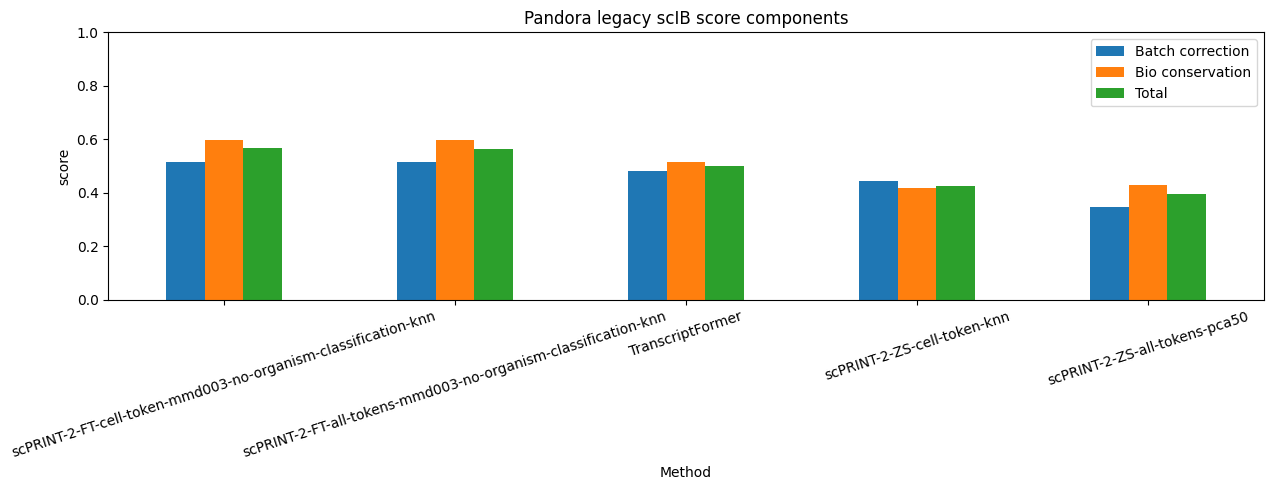

In [12]:
aggregate_columns = ["Batch correction", "Bio conservation", "Total"]
ax = legacy[aggregate_columns].plot.bar(figsize=(13, 5), ylim=(0, 1), rot=18)
ax.set_title("Pandora legacy scIB score components")
ax.set_ylabel("score")
plt.tight_layout()


Method,scPRINT-2-FT-cell-token-mmd003-no-organism-classification-knn,scPRINT-2-FT-all-tokens-mmd003-no-organism-classification-knn,TranscriptFormer,scPRINT-2-ZS-cell-token-knn,scPRINT-2-ZS-all-tokens-pca50
NMI_cluster/label,0.638273,0.637669,0.438533,0.287678,2.855302e-01
ARI_cluster/label,0.625195,0.626750,0.166775,0.110983,1.032239e-01
ASW_label,0.593165,0.593163,0.421728,0.446578,4.215059e-01
ASW_label/batch,0.762955,0.762953,0.787637,0.819412,7.360211e-01
PCR_batch,0.851600,0.851612,0.557037,0.483277,1.111880e-01
cell_cycle_conservation,NaN,NaN,NaN,NaN,NaN
isolated_label_F1,0.219181,0.214325,0.454173,0.191321,2.349021e-01
isolated_label_silhouette,0.522987,0.522987,0.630537,0.545554,5.998164e-01
graph_conn,0.810498,0.810571,0.848231,0.773218,7.577091e-01
kBET,0.133583,0.134790,0.215157,0.136992,1.362936e-01


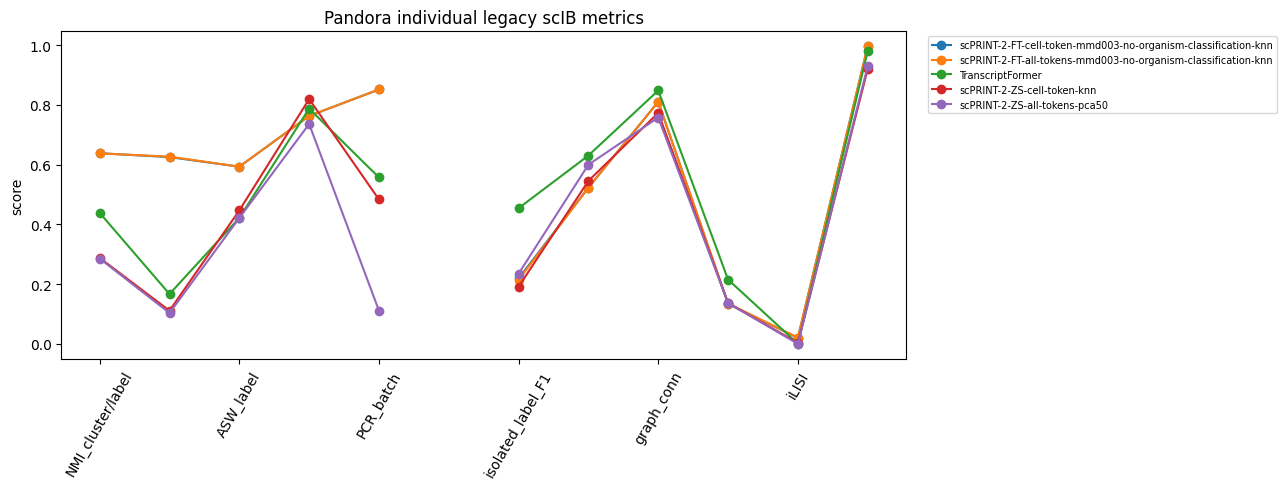

In [13]:
metric_columns = [
    column for column in legacy.columns
    if column not in [*aggregate_columns, "Batch metrics available", "Bio metrics available"]
]
display(legacy[metric_columns].T)
ax = legacy[metric_columns].T.plot(figsize=(13, 5), marker="o", rot=60)
ax.set_title("Pandora individual legacy scIB metrics")
ax.set_ylabel("score")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()


## Evaluator comparison

The two evaluator generations are shown side by side, never merged into one table of interchangeable scores.


,scib_1.1.3_total,scib_metrics_total,legacy_minus_modern
Method,,,
scPRINT-2-FT-cell-token-mmd003-no-organism-classification-knn,0.565833,0.576525,-0.010693
scPRINT-2-FT-all-tokens-mmd003-no-organism-classification-knn,0.565594,0.576595,-0.011001
TranscriptFormer,0.501887,0.451299,0.050588
scPRINT-2-ZS-cell-token-knn,0.427504,0.417819,0.009685
scPRINT-2-ZS-all-tokens-pca50,0.396790,0.354730,0.042060


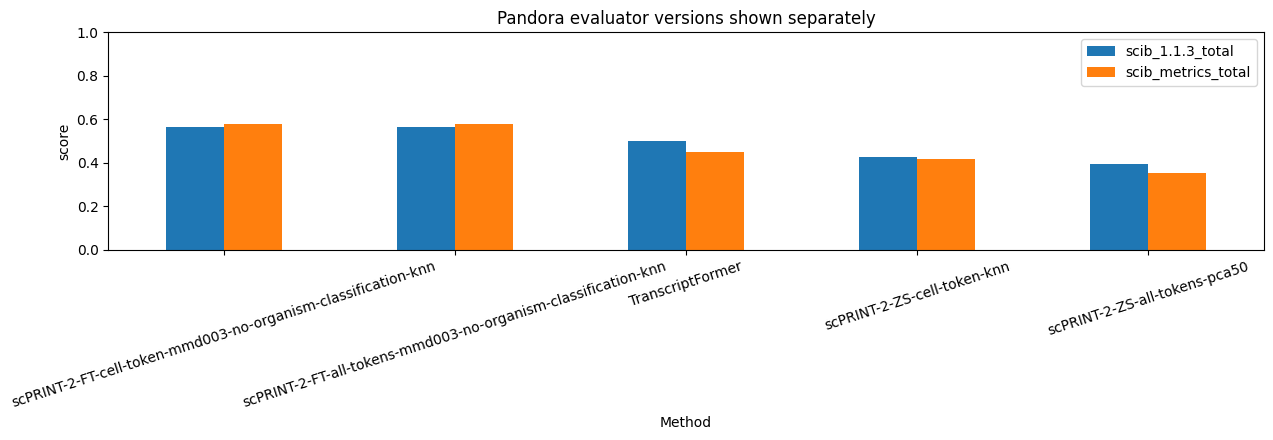

In [14]:
evaluator_columns = ["scib_1.1.3_total", "scib_metrics_total", "legacy_minus_modern"]
display(comparison[evaluator_columns])
ax = comparison[["scib_1.1.3_total", "scib_metrics_total"]].plot.bar(
    figsize=(13, 4.5), ylim=(0, 1), rot=18
)
ax.set_title("Pandora evaluator versions shown separately")
ax.set_ylabel("score")
plt.tight_layout()


## UMAP diagnostics

These UMAPs were produced by the dedicated Pandora UMAP task from the exact graphs used by the matched scores. The notebook reuses all validated outputs.


In [15]:
umap_metadata = json.loads(UMAP_METADATA.read_text())
method_summary = pd.DataFrame(umap_metadata["methods"]).T[
    ["title", "representation_shape", "connectivities_nnz", "prediction_categories"]
]
display(method_summary)
assert {tuple(value) for value in method_summary["representation_shape"]} == {
    (93423, 50), (93423, 64), (93423, 2048)
}


,title,representation_shape,connectivities_nnz,prediction_categories
pca,Expression PCA50,"[93423, 50]",1975394,0
scprint2,scPRINT-2 zero-shot — cell-type token,"[93423, 64]",2009264,122
scprint2_ft,"scPRINT-2 FT — cell-type token, MMD 0.03","[93423, 64]",1856318,25
transcriptformer,TranscriptFormer Metazoa,"[93423, 2048]",2121212,0


### Four matched representations

![Pandora UMAP overview](../../data/results/cross_species_embedding/pandora_lung/pandora_task3_matched_umaps_20260818/pandora_task3_matched_umap_overview.png)


### Organism / species

![Pandora species UMAPs](../../data/results/cross_species_embedding/pandora_lung/pandora_task3_matched_umaps_20260818/pandora_task3_matched_umap_species.png)


### Converted cell-type ontology

![Pandora cell types](../../data/results/cross_species_embedding/pandora_lung/pandora_task3_matched_umaps_20260818/pandora_task3_matched_umap_cell_type_ontology.png)


### Predicted cell type for scPRINT-2 and scPRINT-2 FT

![Pandora predictions](../../data/results/cross_species_embedding/pandora_lung/pandora_task3_matched_umaps_20260818/pandora_task3_matched_umap_predicted_cell_type_ontology.png)


In [16]:
umap_files = pd.Series({
    "overview": UMAP_ROOT / "pandora_task3_matched_umap_overview.png",
    "species": UMAP_ROOT / "pandora_task3_matched_umap_species.png",
    "cell type": UMAP_ROOT / "pandora_task3_matched_umap_cell_type_ontology.png",
    "predicted cell type": UMAP_ROOT / "pandora_task3_matched_umap_predicted_cell_type_ontology.png",
}, name="validated UMAP files")
display(umap_files.map(str).to_frame())
assert umap_files.map(Path.exists).all()


,validated UMAP files
overview,/Users/jkobject/Documents/scPRINT/data/results...
species,/Users/jkobject/Documents/scPRINT/data/results...
cell type,/Users/jkobject/Documents/scPRINT/data/results...
predicted cell type,/Users/jkobject/Documents/scPRINT/data/results...


## Interpretation boundary

The clean comparison validates complete pipelines on a fixed atlas. It does not attribute a score difference to MMD, KNN, model family, or evaluator without a matched ablation.
